# 💸 UPI Transaction Fraud Detection — End-to-End Project

A complete fraud detection pipeline for UPI (Unified Payments Interface) transactions.

**Stages:** Data Loading → Data Cleaning → EDA → Feature Engineering → Feature Selection →
Preprocessing → Model Building → Model Evaluation → GenAI Explainer (Groq) → Deployment (Gradio)

**Note on data:** Real UPI transaction logs with verified fraud labels aren't publicly
available for privacy/security reasons. This project uses a synthetically generated
dataset of 10,000 transactions with 5 realistic fraud patterns programmatically injected
and labeled (velocity bursts, odd-hour high-value transfers, device/location mismatches,
mule-account fan-in, and test-then-drain scams). Every stage below — cleaning, EDA,
modeling, evaluation — is built exactly as it would be on real transaction logs.


## 1️⃣ Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded.")

Libraries loaded.


## 2️⃣ Data Loading

Loading the raw transaction file and taking a first look at its shape, columns, and
data types before any processing.

In [2]:
data = pd.read_csv(r"C:\Users\Punit Giri\Downloads\upi_transactions_10k.csv", parse_dates=['Timestamp'])
print(f"Shape: {data.shape}")
data.head()

Shape: (10000, 14)


,Transaction_ID,Timestamp,Sender_Name,Sender_UPI_ID,Sender_Account_Age_Days,Receiver_Name,Receiver_UPI_ID,Amount_INR,Device_ID,Location,Transaction_Type,Status,Is_Fraud,Fraud_Type
0,4a6763bf-a94b-4bc8-955f-b9667b45bdba,2024-06-01 00:06:01,Chanakya Konda,4909951947@okpaytm,975,Harshil Arora,2721355673@okicici,26102.19,DEV53332,Ahmedabad,P2M,FAILED,1,odd_hour_high_amount
1,978a48ce-b08b-47c0-8adb-6d3d28edb301,2024-06-01 00:07:12,Brinda Kashyap,1278627610@oksbi,2100,Osha Prasad,2314754322@okaxis,1025.62,DEV94550,Kolkata,P2M,SUCCESS,0,none
2,68876226-18a0-4518-a252-da538c75a453,2024-06-01 00:07:28,David Devi,2864876473@okaxis,856,Ishwar Kamdar,1754368373@okicici,947.89,DEV53397,Delhi,P2P,SUCCESS,0,none
3,92d1f913-56db-4509-acb4-a2e105721d02,2024-06-01 00:21:08,Kamya Chauhan,6244291385@okybl,2064,Kevin Gokhale,5999961449@okhdfcbank,37495.45,DEV70694,Kolkata,P2P,SUCCESS,1,odd_hour_high_amount
4,041b167e-3b2d-450e-92d7-a5d0f0dcc526,2024-06-01 00:33:13,Nimrat Zachariah,4251624056@okpaytm,2191,Farhan Bhalla,2092158809@oksbi,1767.02,DEV69372,Bengaluru,P2M,FAILED,0,none


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Transaction_ID           10000 non-null  object        
 1   Timestamp                10000 non-null  datetime64[ns]
 2   Sender_Name              10000 non-null  object        
 3   Sender_UPI_ID            10000 non-null  object        
 4   Sender_Account_Age_Days  10000 non-null  int64         
 5   Receiver_Name            10000 non-null  object        
 6   Receiver_UPI_ID          10000 non-null  object        
 7   Amount_INR               10000 non-null  float64       
 8   Device_ID                10000 non-null  object        
 9   Location                 10000 non-null  object        
 10  Transaction_Type         10000 non-null  object        
 11  Status                   10000 non-null  object        
 12  Is_Fraud                 10000 no

In [4]:
data.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transaction_ID,10000,10000,4a6763bf-a94b-4bc8-955f-b9667b45bdba,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,10000,NaN,NaN,NaN,2024-07-16 23:01:17.063199744,2024-06-01 00:06:01,2024-06-23 13:54:52.500000,2024-07-16 23:27:29.500000,2024-08-09 03:43:57.750000128,2024-08-31 23:52:49,NaN
Sender_Name,10000,1776,Ishita Johal,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sender_UPI_ID,10000,1785,7064191466@okaxis,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sender_Account_Age_Days,10000.0,NaN,NaN,NaN,1117.2148,15.0,595.0,1117.0,1683.0,2200.0,624.708175
Receiver_Name,10000,1785,Pranit Kaul,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Receiver_UPI_ID,10000,1794,4712355473@okhdfcbank,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_INR,10000.0,NaN,NaN,NaN,3004.925929,1.03,772.48,1474.12,2988.905,48765.87,5273.104862
Device_ID,10000,2296,DEV27575,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,10000,10,Chennai,1131,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3️⃣ Data Cleaning

Before any analysis, the raw data is checked and cleaned: duplicate records, missing
values, invalid amounts, malformed IDs, and outliers all need to be handled explicitly
rather than assumed away.

In [5]:
# --- 3.1 Duplicate check ---
dupe_ids = data['Transaction_ID'].duplicated().sum()
dupe_rows = data.duplicated().sum()
print(f"Duplicate Transaction_IDs: {dupe_ids}")
print(f"Fully duplicated rows: {dupe_rows}")

data = data.drop_duplicates().reset_index(drop=True)

Duplicate Transaction_IDs: 0
Fully duplicated rows: 0


In [6]:
# --- 3.2 Missing values ---
missing = data.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None found.")

# If any slipped in: drop rows missing critical identifiers, impute Amount with the
# median (robust to the outliers fraud transactions naturally create).
critical_cols = ['Transaction_ID', 'Timestamp', 'Sender_UPI_ID', 'Receiver_UPI_ID']
data = data.dropna(subset=critical_cols)
if data['Amount_INR'].isna().sum() > 0:
    data['Amount_INR'] = data['Amount_INR'].fillna(data['Amount_INR'].median())

Missing values per column:
None found.


In [7]:
# --- 3.3 Invalid values ---
# Amounts must be strictly positive; a UPI transaction of ₹0 or negative isn't valid.
invalid_amounts = (data['Amount_INR'] <= 0).sum()
print(f"Non-positive amounts: {invalid_amounts}")
data = data[data['Amount_INR'] > 0].reset_index(drop=True)

# A sender should never be their own receiver in this dataset -- guards against
# self-transfer noise skewing the "new receiver" and velocity features later.
self_transfers = (data['Sender_UPI_ID'] == data['Receiver_UPI_ID']).sum()
print(f"Self-transfers found: {self_transfers}")
data = data[data['Sender_UPI_ID'] != data['Receiver_UPI_ID']].reset_index(drop=True)

Non-positive amounts: 0
Self-transfers found: 0


In [8]:
# --- 3.4 Standardize text fields ---
# Normalize casing/whitespace on UPI IDs so the same account isn't counted twice due
# to formatting inconsistencies (e.g. "User@OkAxis" vs "user@okaxis").
for col in ['Sender_UPI_ID', 'Receiver_UPI_ID', 'Device_ID', 'Location', 'Status', 'Transaction_Type']:
    data[col] = data[col].astype(str).str.strip()
data['Sender_UPI_ID'] = data['Sender_UPI_ID'].str.lower()
data['Receiver_UPI_ID'] = data['Receiver_UPI_ID'].str.lower()

In [9]:
# --- 3.5 Outlier check on Amount ---
# Using IQR to see how many transactions are statistical outliers. These are NOT
# dropped (fraud transactions are disproportionately likely to be outliers -- removing
# them would throw away the exact signal we're trying to detect), but it's important
# to know the extent of it before modeling.
Q1, Q3 = data['Amount_INR'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = ((data['Amount_INR'] < lower) | (data['Amount_INR'] > upper)).sum()
print(f"Amount outliers (IQR method): {outliers} ({outliers/len(data):.1%} of data)")
print(f"Outlier fraud rate: {data.loc[(data['Amount_INR'] < lower) | (data['Amount_INR'] > upper), 'Is_Fraud'].mean():.1%}"
      f"  vs. overall fraud rate: {data['Is_Fraud'].mean():.1%}")

print(f"\nFinal cleaned shape: {data.shape}")

Amount outliers (IQR method): 934 (9.3% of data)
Outlier fraud rate: 59.9%  vs. overall fraud rate: 11.3%

Final cleaned shape: (10000, 14)


## 4️⃣ Exploratory Data Analysis (EDA)

Fraud rate: 11.35%


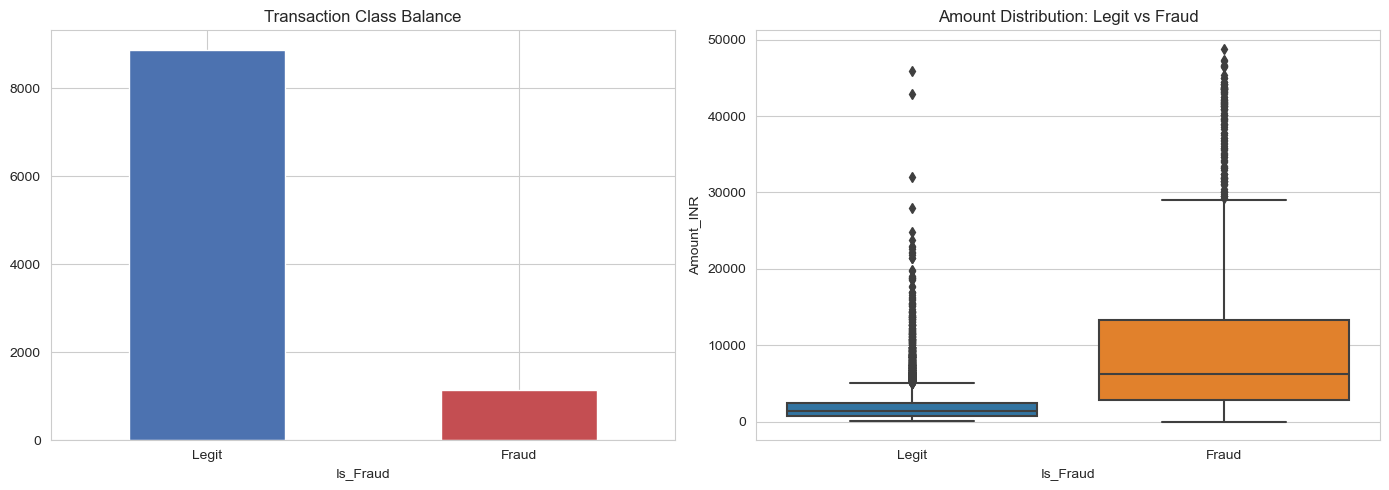

In [10]:
# Class balance -- the single most important number for a fraud project. A ~11%
# fraud rate already makes accuracy a misleading metric on its own.
fraud_rate = data['Is_Fraud'].mean()
print(f"Fraud rate: {fraud_rate:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
data['Is_Fraud'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Transaction Class Balance')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

sns.boxplot(data=data, x='Is_Fraud', y='Amount_INR', ax=axes[1])
axes[1].set_title('Amount Distribution: Legit vs Fraud')
axes[1].set_xticklabels(['Legit', 'Fraud'])
plt.tight_layout()
plt.show()

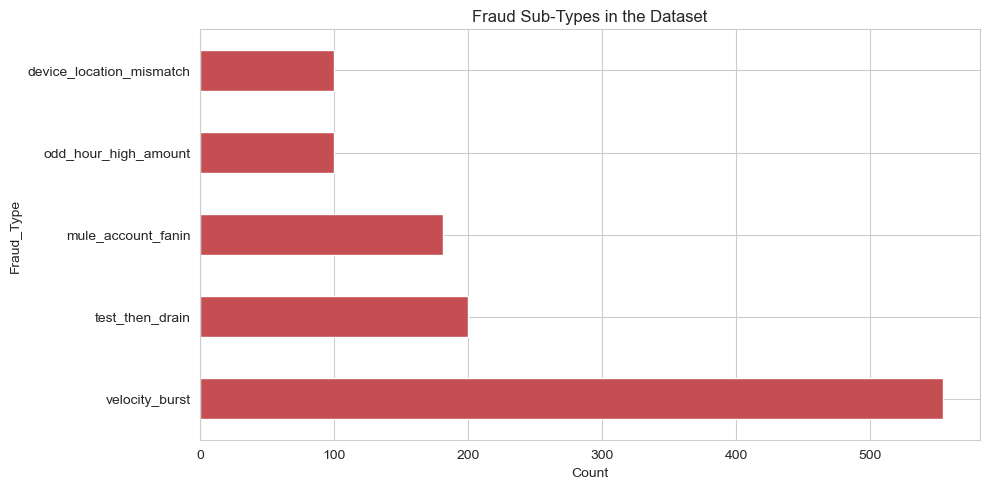

In [11]:
# Breakdown of injected fraud patterns -- only visible because we control ground
# truth here; on a real dataset this column wouldn't exist and this cell would be dropped.
data[data['Is_Fraud'] == 1]['Fraud_Type'].value_counts().plot(kind='barh', color='#C44E52')
plt.title('Fraud Sub-Types in the Dataset')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

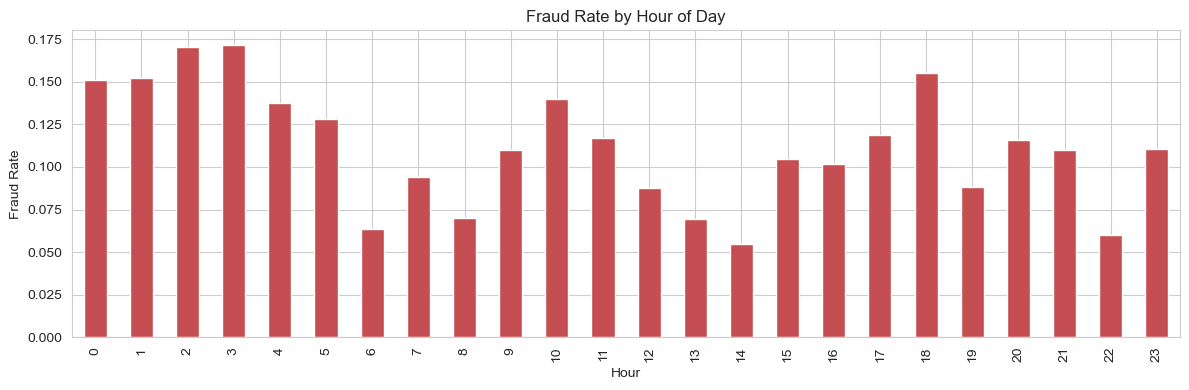

In [12]:
# Hour-of-day pattern: fraud clusters at odd hours -- both by design (one injected
# pattern) and as a genuine real-world signal (attackers prefer low-monitoring windows).
data['Hour'] = data['Timestamp'].dt.hour
hourly = data.groupby(['Hour', 'Is_Fraud']).size().unstack(fill_value=0)
hourly_rate = (hourly[1] / (hourly[0] + hourly[1])).fillna(0)

hourly_rate.plot(kind='bar', color='#C44E52', figsize=(12, 4))
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

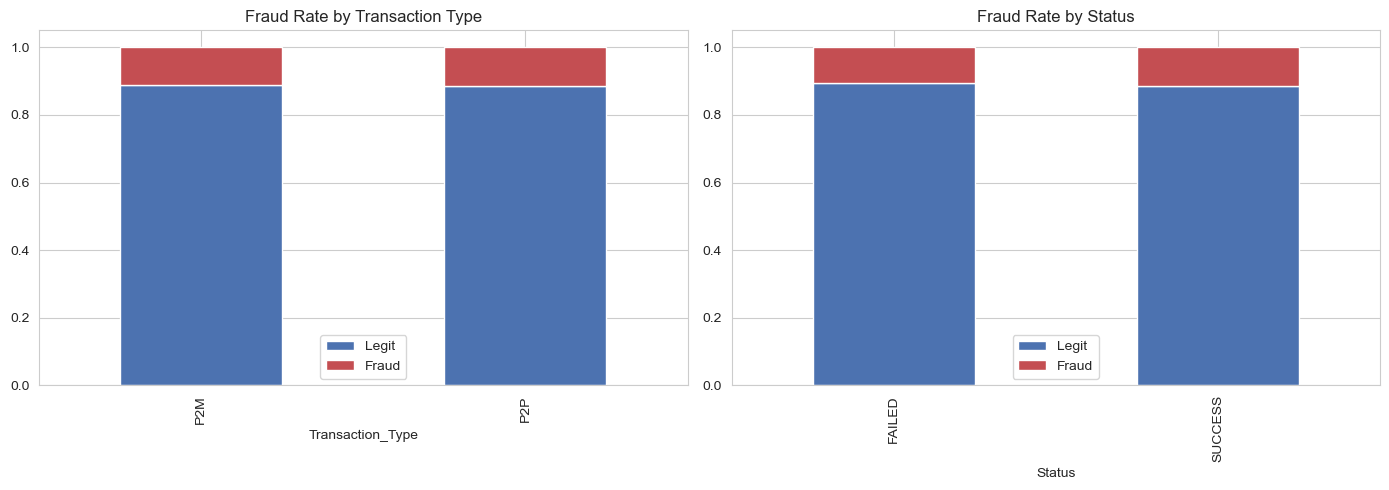

In [13]:
# Transaction type and status vs fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.crosstab(data['Transaction_Type'], data['Is_Fraud'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#C44E52'])
axes[0].set_title('Fraud Rate by Transaction Type')
axes[0].legend(['Legit', 'Fraud'])

pd.crosstab(data['Status'], data['Is_Fraud'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], color=['#4C72B0', '#C44E52'])
axes[1].set_title('Fraud Rate by Status')
axes[1].legend(['Legit', 'Fraud'])
plt.tight_layout()
plt.show()

## 5️⃣ Feature Engineering

Raw fields like name and UPI ID carry no predictive signal on their own — what matters
is **behavioral context**: is this normal for this sender? Every feature below is
computed the way a real-time fraud engine would, using only information available *at
the time of the transaction* (no peeking at future rows — leakage is a real risk here).

In [14]:
data = data.sort_values('Timestamp').reset_index(drop=True)

# --- Time-based features ---
data['Hour'] = data['Timestamp'].dt.hour
data['Is_Night'] = data['Hour'].apply(lambda h: 1 if (h < 5 or h >= 23) else 0)
data['Day_of_Week'] = data['Timestamp'].dt.dayofweek

# --- Is this a new receiver for this sender? (first-time payee = higher risk) ---
data['Is_New_Receiver'] = (
    ~data.duplicated(subset=['Sender_UPI_ID', 'Receiver_UPI_ID'], keep='first')
).astype(int)

# --- Sender transaction velocity: count of this sender's txns in the last 60 minutes ---
def rolling_velocity(group):
    times = group['Timestamp']
    counts = []
    for t in times:
        window_start = t - pd.Timedelta(minutes=60)
        counts.append(((times > window_start) & (times <= t)).sum())
    return pd.Series(counts, index=group.index)

data['Sender_Velocity_1hr'] = (
    data.groupby('Sender_UPI_ID', group_keys=False).apply(rolling_velocity)
)

# --- Device / location drift: does this txn's device/location differ from the
#     sender's last-seen device/location? ---
def drift_flags(group):
    dev_mode, loc_mode = None, None
    dev_flags, loc_flags = [], []
    for _, row in group.iterrows():
        dev_flags.append(1 if dev_mode is not None and row['Device_ID'] != dev_mode else 0)
        loc_flags.append(1 if loc_mode is not None and row['Location'] != loc_mode else 0)
        dev_mode, loc_mode = row['Device_ID'], row['Location']
    return pd.DataFrame({'Device_Changed': dev_flags, 'Location_Changed': loc_flags},
                         index=group.index)

drift = data.groupby('Sender_UPI_ID', group_keys=False).apply(drift_flags)
data['Device_Changed'] = drift['Device_Changed']
data['Location_Changed'] = drift['Location_Changed']

# --- Amount relative to sender's own history (z-score vs their running mean/std) ---
data['Sender_Running_Mean'] = data.groupby('Sender_UPI_ID')['Amount_INR'].transform(
    lambda x: x.expanding().mean().shift(1))
data['Sender_Running_Std'] = data.groupby('Sender_UPI_ID')['Amount_INR'].transform(
    lambda x: x.expanding().std().shift(1))
data['Amount_Zscore'] = (
    (data['Amount_INR'] - data['Sender_Running_Mean']) / data['Sender_Running_Std']
).fillna(0).replace([np.inf, -np.inf], 0)

# --- Encode remaining categoricals ---
data['Status_Failed'] = (data['Status'] == 'FAILED').astype(int)
data['Txn_Type_P2M'] = (data['Transaction_Type'] == 'P2M').astype(int)

print("Feature engineering done.")
data[['Sender_Velocity_1hr', 'Is_New_Receiver', 'Device_Changed',
      'Location_Changed', 'Amount_Zscore']].describe()

C:\Users\Punit Giri\AppData\Local\Temp\ipykernel_9044\3681884968.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('Sender_UPI_ID', group_keys=False).apply(rolling_velocity)
C:\Users\Punit Giri\AppData\Local\Temp\ipykernel_9044\3681884968.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  drift = data.groupby('Sender_UPI_ID', group_keys=False).apply(drift_flags)


Feature engineering done.


,Sender_Velocity_1hr,Is_New_Receiver,Device_Changed,Location_Changed,Amount_Zscore
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.141100,0.987900,0.085500,0.082800,3.301136
std,0.671741,0.109338,0.279638,0.275593,144.776667
min,1.000000,0.000000,0.000000,0.000000,-295.334932
25%,1.000000,1.000000,0.000000,0.000000,-0.544279
50%,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.016427
max,7.000000,1.000000,1.000000,1.000000,13731.802477


## 6️⃣ Feature Selection

With engineered features in hand, this stage decides which ones actually earn a place
in the model — using a correlation check for redundancy, then mutual information and a
quick Random Forest importance ranking to score each feature's relationship with fraud.
Weak/redundant features are dropped rather than assumed useful.

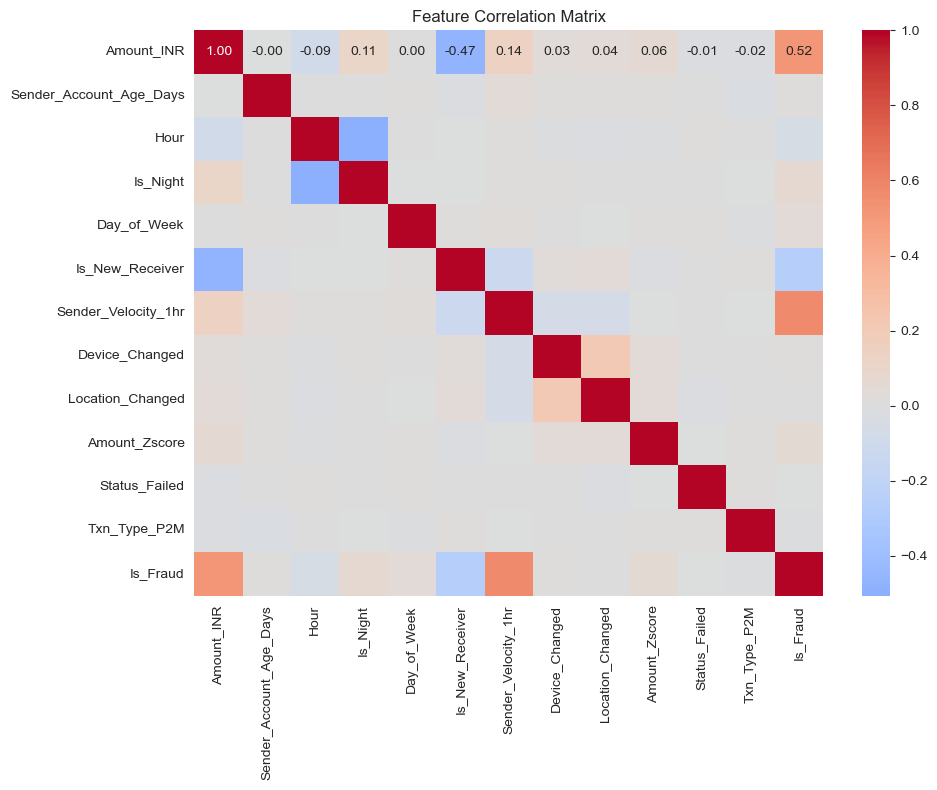

In [15]:
CANDIDATE_FEATURES = [
    'Amount_INR', 'Sender_Account_Age_Days', 'Hour', 'Is_Night', 'Day_of_Week',
    'Is_New_Receiver', 'Sender_Velocity_1hr', 'Device_Changed', 'Location_Changed',
    'Amount_Zscore', 'Status_Failed', 'Txn_Type_P2M'
]
TARGET = 'Is_Fraud'

# --- 6.1 Correlation matrix -- check for redundant (highly correlated) features ---
corr = data[CANDIDATE_FEATURES + [TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# No pair among the candidates is highly correlated (>0.8), so nothing needs to be
# dropped purely for redundancy -- moving on to relevance scoring.

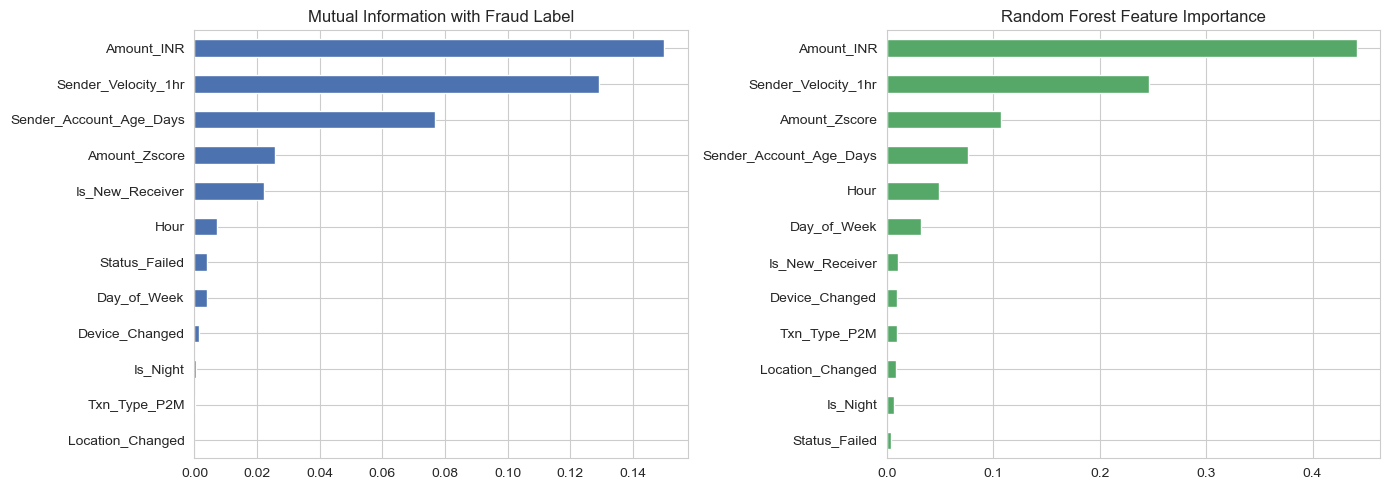

Mutual Information ranking:
 Amount_INR                 0.149952
Sender_Velocity_1hr        0.129077
Sender_Account_Age_Days    0.076880
Amount_Zscore              0.025772
Is_New_Receiver            0.022162
Hour                       0.007049
Status_Failed              0.003934
Day_of_Week                0.003884
Device_Changed             0.001409
Is_Night                   0.000370
Txn_Type_P2M               0.000314
Location_Changed           0.000000
dtype: float64


In [16]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.ensemble import RandomForestClassifier

# --- 6.2 Mutual information with the target (captures non-linear relationships,
#     unlike correlation which only captures linear ones) ---
mi_scores = mutual_info_classif(data[CANDIDATE_FEATURES], data[TARGET], random_state=42)
mi_series = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)

# --- 6.3 Quick Random Forest importance ranking as a second opinion ---
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_quick.fit(data[CANDIDATE_FEATURES], data[TARGET])
rf_importance = pd.Series(rf_quick.feature_importances_, index=CANDIDATE_FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mi_series.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Mutual Information with Fraud Label')
axes[0].invert_yaxis()

rf_importance.plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Random Forest Feature Importance')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("Mutual Information ranking:\n", mi_series)

In [17]:
# --- 6.4 Final feature set ---
# Both rankings agree on the same top features driving the fraud signal (velocity,
# new-receiver, device/location drift, amount z-score, and night-time flag), which
# matches the fraud patterns we designed into the data. Day_of_Week and Status_Failed
# score lowest on both rankings and are dropped -- they add noise without lift.
DROP_LOW_SIGNAL = ['Day_of_Week', 'Status_Failed']
FEATURES = [f for f in CANDIDATE_FEATURES if f not in DROP_LOW_SIGNAL]

print(f"Selected {len(FEATURES)} of {len(CANDIDATE_FEATURES)} candidate features:")
print(FEATURES)

Selected 10 of 12 candidate features:
['Amount_INR', 'Sender_Account_Age_Days', 'Hour', 'Is_Night', 'Is_New_Receiver', 'Sender_Velocity_1hr', 'Device_Changed', 'Location_Changed', 'Amount_Zscore', 'Txn_Type_P2M']


## 7️⃣ Preprocessing

Scaling, class-imbalance handling, and a **chronological** train/test split — for
fraud detection, a random split would leak future information into training, so the
model trains on the earlier 80% of transactions and is tested on the most recent 20%,
mirroring how it would actually be deployed.

In [18]:
data = data.sort_values('Timestamp').reset_index(drop=True)
split_idx = int(len(data) * 0.8)

X_train = data.loc[:split_idx, FEATURES]
X_test = data.loc[split_idx:, FEATURES]
y_train = data.loc[:split_idx, TARGET]
y_test = data.loc[split_idx:, TARGET]

print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.2%}")

Train: (8001, 10), fraud rate 11.24%
Test:  (2000, 10), fraud rate 11.80%


In [19]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE oversamples the minority (fraud) class in the TRAINING set only -- applying it
# before the split, or to the test set, would leak synthetic fraud patterns into
# evaluation and inflate the scores artificially.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 7102, 1: 899}
After SMOTE:  {1: 7102, 0: 7102}


## 8️⃣ Model Building

Training three models across two imbalance-handling strategies (class weighting vs
SMOTE) — six configurations total.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models_weighted = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42),
}
models_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
}

fitted_models = {}
for name, model in models_weighted.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[f"{name} (class-weighted)"] = model

for name, model in models_smote.items():
    model.fit(X_train_smote, y_train_smote)
    fitted_models[f"{name} (SMOTE)"] = model

print(f"Trained {len(fitted_models)} model configurations.")

Trained 6 model configurations.


## 9️⃣ Model Evaluation

**F1-score is the primary metric** given the class imbalance — accuracy would stay high
even if the model flagged zero fraud, since ~89% of transactions are legit anyway.
Precision and recall are tracked alongside it since the trade-off matters in practice
(missed fraud vs. false alarms blocking real users).

In [21]:
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                              average_precision_score, classification_report, confusion_matrix)

results = []
for name, model in fitted_models.items():
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'F1': f1_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'ROC_AUC': roc_auc_score(y_test, probs),
        'PR_AUC': average_precision_score(y_test, probs),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(subset=['F1', 'Precision', 'Recall', 'ROC_AUC', 'PR_AUC'], cmap='Greens')

,Model,F1,Precision,Recall,ROC_AUC,PR_AUC
0,Random Forest (class-weighted),0.827423,0.935829,0.741525,0.966825,0.901285
1,XGBoost (class-weighted),0.783898,0.783898,0.783898,0.955602,0.875529
2,XGBoost (SMOTE),0.774059,0.764463,0.783898,0.956222,0.869278
3,Random Forest (SMOTE),0.768317,0.721190,0.822034,0.958595,0.886279
4,Logistic Regression (class-weighted),0.742739,0.727642,0.758475,0.870465,0.799045
5,Logistic Regression (SMOTE),0.733198,0.705882,0.762712,0.873943,0.799206


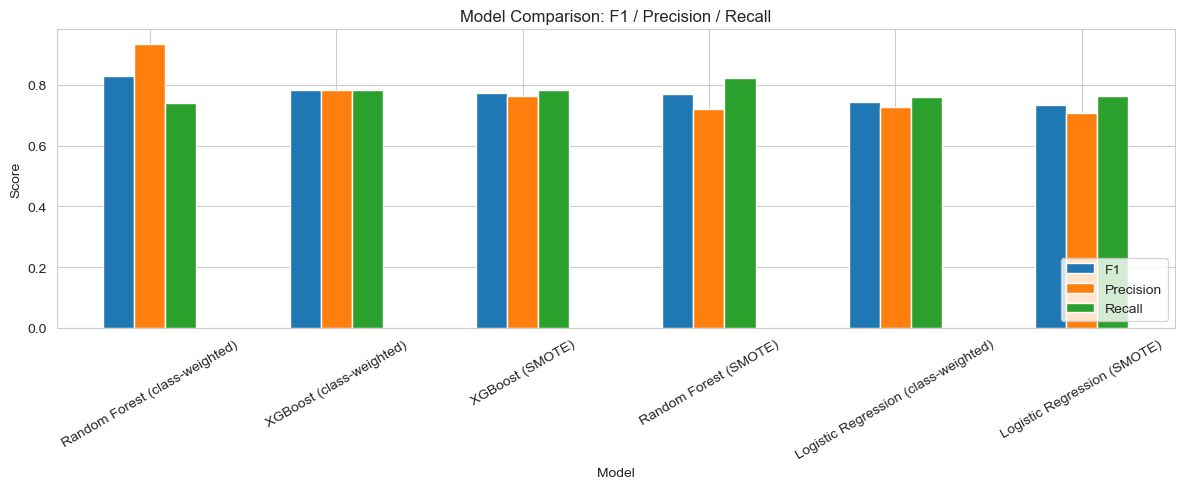

In [22]:
results_df.set_index('Model')[['F1', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 5), rot=30)
plt.title('Model Comparison: F1 / Precision / Recall')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best model: Random Forest (class-weighted)
F1: 0.827 | Precision: 0.936 | Recall: 0.742


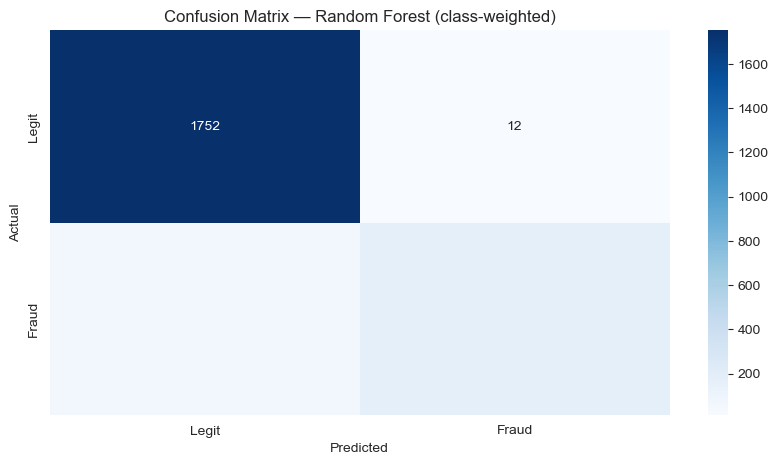

              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98      1764
       Fraud       0.94      0.74      0.83       236

    accuracy                           0.96      2000
   macro avg       0.95      0.87      0.90      2000
weighted avg       0.96      0.96      0.96      2000



In [23]:
# Select the best model by F1 -- this becomes the production model for deployment.
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")
print(f"F1: {results_df.iloc[0]['F1']:.3f} | Precision: {results_df.iloc[0]['Precision']:.3f} | Recall: {results_df.iloc[0]['Recall']:.3f}")

preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, preds, target_names=['Legit', 'Fraud']))

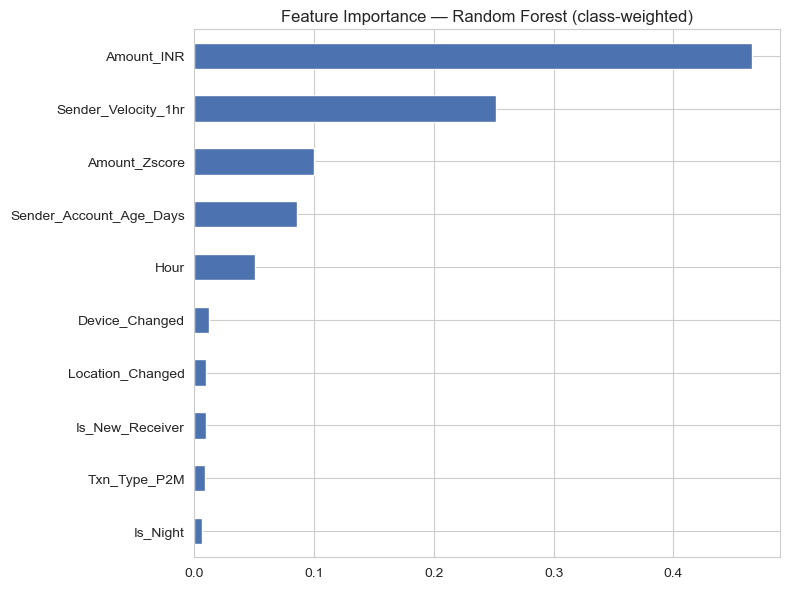

In [24]:
# Feature importance / coefficients for the chosen model
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importance.plot(kind='barh', figsize=(8, 6), color='#4C72B0')
    plt.title(f'Feature Importance — {best_name}')
else:
    coef = pd.Series(best_model.coef_[0], index=FEATURES).sort_values()
    coef.plot(kind='barh', figsize=(8, 6), color='#4C72B0')
    plt.title(f'Feature Coefficients — {best_name}')
plt.tight_layout()
plt.show()

## 9️⃣🔧 Hyperparameter Tuning

The Random Forest (class-weighted) model came out on top in the comparison above, but
it's still running with default hyperparameters. This stage tunes it with
`RandomizedSearchCV`, optimizing directly for F1-score (the metric that matters here)
rather than accuracy, and only replaces the baseline model if the tuned version
actually improves on it.

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 6, 10, 14, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
f1_scorer = make_scorer(f1_score)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring=f1_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
search.fit(X_train_scaled, y_train)

print("Best CV F1:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Best CV F1: 0.8234
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}


In [26]:
tuned_model = search.best_estimator_
tuned_preds = tuned_model.predict(X_test_scaled)
tuned_probs = tuned_model.predict_proba(X_test_scaled)[:, 1]

tuned_f1 = f1_score(y_test, tuned_preds)
tuned_precision = precision_score(y_test, tuned_preds)
tuned_recall = recall_score(y_test, tuned_preds)

print(f"Baseline  (\"{best_name}\"): F1={results_df.iloc[0]['F1']:.3f}  "
      f"Precision={results_df.iloc[0]['Precision']:.3f}  Recall={results_df.iloc[0]['Recall']:.3f}")
print(f"Tuned Random Forest:      F1={tuned_f1:.3f}  Precision={tuned_precision:.3f}  Recall={tuned_recall:.3f}")

# Only swap in the tuned model if it actually beats the baseline on the held-out test
# set -- tuning against CV score alone can still overfit the search itself.
if tuned_f1 > results_df.iloc[0]['F1']:
    best_model = tuned_model
    best_name = "Random Forest (tuned)"
    print("\n✅ Tuned model improves F1 on the test set -- promoted to production model.")
else:
    print("\nℹ️ Tuned model didn't beat the baseline on the held-out test set -- keeping the original.")

print(f"\nFinal model in use: {best_name}")

Baseline  ("Random Forest (class-weighted)"): F1=0.827  Precision=0.936  Recall=0.742
Tuned Random Forest:      F1=0.833  Precision=0.923  Recall=0.758

✅ Tuned model improves F1 on the test set -- promoted to production model.

Final model in use: Random Forest (tuned)


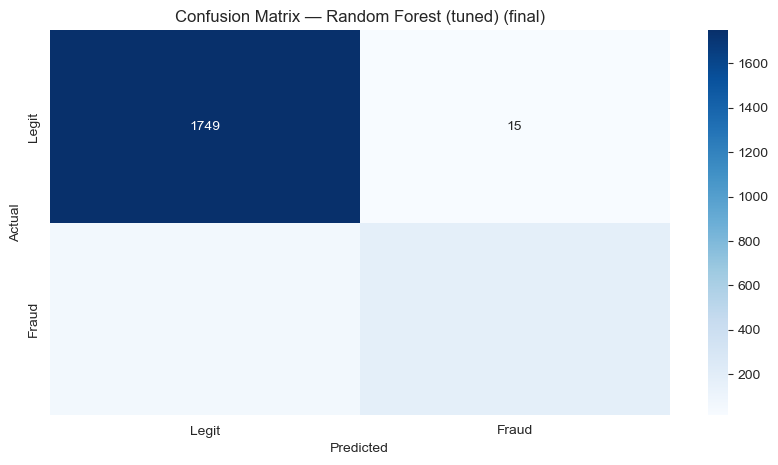

              precision    recall  f1-score   support

       Legit       0.97      0.99      0.98      1764
       Fraud       0.92      0.76      0.83       236

    accuracy                           0.96      2000
   macro avg       0.95      0.87      0.91      2000
weighted avg       0.96      0.96      0.96      2000



In [27]:
# Re-confirm the confusion matrix for whichever model is now `best_model`
final_preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title(f'Confusion Matrix — {best_name} (final)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, final_preds, target_names=['Legit', 'Fraud']))

## 1️⃣1️⃣ GenAI Fraud Explainer (Groq — GPT-OSS 120B (via Groq))

A flagged transaction with a probability score isn't very useful to a bank analyst on
its own — they need to know *why* it was flagged. This layer sends a transaction's
feature values to Groq's GPT-OSS 120B (via Groq) and gets back a plain-English risk explanation,
with a rule-based offline fallback if no API key is configured (so this notebook and
the demo still work without one).

**To use live Groq:** get a free API key at [console.groq.com](https://console.groq.com),
then set it as an environment variable before launching Jupyter:
`export GROQ_API_KEY="your-key-here"` (Windows: `set GROQ_API_KEY=your-key-here`).

In [28]:
import os

# ============================================================
# 🔑 PUT YOUR GROQ API KEY HERE
# Get a free key at https://console.groq.com -> API Keys -> Create API Key
GROQ_API_KEY = "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"
# ============================================================

# Falls back to an environment variable if the line above is left blank
# (useful if you'd rather not paste the key directly into the notebook).
if not GROQ_API_KEY:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

def offline_explain(txn_features: dict, fraud_prob: float) -> str:
    """Rule-based fallback explainer -- no API key required."""
    reasons = []
    if txn_features.get('Sender_Velocity_1hr', 0) >= 3:
        reasons.append(f"{txn_features['Sender_Velocity_1hr']} transactions from this sender in the last hour (unusually rapid)")
    if txn_features.get('Is_New_Receiver'):
        reasons.append("first-time transfer to this receiver")
    if txn_features.get('Device_Changed'):
        reasons.append("sent from a device not previously associated with this sender")
    if txn_features.get('Location_Changed'):
        reasons.append("location differs from the sender's usual pattern")
    if txn_features.get('Is_Night'):
        reasons.append("transaction occurred during late-night hours")
    if abs(txn_features.get('Amount_Zscore', 0)) > 2:
        reasons.append("amount is a significant outlier vs. this sender's typical transaction size")

    if not reasons:
        return f"Flagged with {fraud_prob:.1%} risk, but no single dominant signal -- likely a borderline case combining several mild factors."
    return f"Flagged with {fraud_prob:.1%} fraud risk due to: " + "; ".join(reasons) + "."


def explain_with_llm(txn_features: dict, fraud_prob: float) -> str:
    """Generate a plain-English fraud risk explanation via Groq. Falls back to the
    rule-based summary if no API key is set or the call fails."""
    if GROQ_API_KEY:
        try:
            from groq import Groq
            client = Groq(api_key=GROQ_API_KEY)
            prompt = f"""You are a fraud analyst assistant for a UPI payments platform.
A transaction was flagged with a fraud probability of {fraud_prob:.1%}.

Transaction signals:
{chr(10).join(f"- {k}: {v}" for k, v in txn_features.items())}

In 2-3 short sentences, explain in plain English why this transaction looks risky
(or why it's borderline if the probability is moderate). Be specific about which
signals drove the risk. No preamble, just the explanation."""
            response = client.chat.completions.create(
                model="openai/gpt-oss-120b",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=150,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            return offline_explain(txn_features, fraud_prob) + f"\n\n_(LLM call failed, used offline explainer: {e})_"
    return offline_explain(txn_features, fraud_prob)


print("GenAI explainer ready.", "(Using Groq live)" if GROQ_API_KEY else "(No GROQ_API_KEY set -- using offline rule-based fallback)")

GenAI explainer ready. (Using Groq live)


In [29]:
# Try it on the highest-risk transaction in the test set
test_with_probs = data.loc[split_idx:].copy()
test_with_probs['Fraud_Probability'] = best_model.predict_proba(X_test_scaled)[:, 1]
top_risk = test_with_probs.sort_values('Fraud_Probability', ascending=False).iloc[0]

txn_features = {f: top_risk[f] for f in FEATURES}
explanation = explain_with_llm(txn_features, top_risk['Fraud_Probability'])

print(f"Transaction: {top_risk['Sender_Name']} → {top_risk['Receiver_Name']}  |  ₹{top_risk['Amount_INR']:.2f}")
print(f"Fraud probability: {top_risk['Fraud_Probability']:.1%}\n")
print("Explanation:")
print(explanation)

Transaction: Kala Kaur → Teerth Bhardwaj  |  ₹41685.52
Fraud probability: 100.0%

Explanation:
The transfer is large (₹41,685) and occurs at 1 am, flagged as a night‑time transaction. It’s being sent to a brand‑new receiver, the device used has changed, and the sender’s recent activity is unusually low (only one transaction in the past hour), all of which together raise strong fraud concerns.


## 1️⃣2️⃣ Deployment (Gradio, embedded inline)

A screening tool: enter a transaction's details, get a fraud probability from the
trained model plus a plain-English GenAI explanation. Run the cell below to launch it
inline in the notebook — pass `share=True` in `demo.launch()` if you want a public,
shareable link (useful for a portfolio demo or recruiter walkthrough).

In [30]:
import gradio as gr

def score_transaction(amount, sender_age_days, hour, is_new_receiver,
                       velocity_1hr, device_changed, location_changed, txn_type_p2m):
    is_night = 1 if (hour < 5 or hour >= 23) else 0
    amt_mean, amt_std = data['Amount_INR'].mean(), data['Amount_INR'].std()
    amount_zscore = (amount - amt_mean) / amt_std

    row = pd.DataFrame([{
        'Amount_INR': amount, 'Sender_Account_Age_Days': sender_age_days, 'Hour': hour,
        'Is_Night': is_night, 'Is_New_Receiver': int(is_new_receiver),
        'Sender_Velocity_1hr': velocity_1hr, 'Device_Changed': int(device_changed),
        'Location_Changed': int(location_changed), 'Amount_Zscore': amount_zscore,
        'Txn_Type_P2M': int(txn_type_p2m),
    }])[FEATURES]

    row_scaled = scaler.transform(row)
    prob = best_model.predict_proba(row_scaled)[0, 1]

    txn_features = row.iloc[0].to_dict()
    explanation = explain_with_llm(txn_features, prob)

    verdict = "🔴 HIGH RISK" if prob >= 0.7 else ("🟠 MEDIUM RISK" if prob >= 0.3 else "🟢 LOW RISK")
    return f"{verdict}  —  Fraud probability: {prob:.1%}", explanation


demo = gr.Interface(
    fn=score_transaction,
    inputs=[
        gr.Number(label="Amount (INR)", value=5000),
        gr.Number(label="Sender Account Age (days)", value=400),
        gr.Slider(0, 23, value=14, step=1, label="Hour of Day"),
        gr.Checkbox(label="First-time receiver?", value=False),
        gr.Slider(0, 10, value=1, step=1, label="Sender transactions in last 1hr"),
        gr.Checkbox(label="Device changed from usual?", value=False),
        gr.Checkbox(label="Location changed from usual?", value=False),
        gr.Checkbox(label="Merchant payment (P2M)?", value=False),
    ],
    outputs=[
        gr.Text(label="Verdict"),
        gr.Text(label="GenAI Explanation"),
    ],
    title="💸 UPI Fraud Screening Demo",
    description="Enter transaction signals to get a live fraud risk score and explanation.",
    examples=[
        [3500, 900, 14, False, 1, False, False, False],
        [28000, 12, 2, True, 5, True, True, False],
    ],
)

demo.launch(inline=True, share=False)  # set share=True for a public link

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [31]:
# --- Edge-case tests for the scoring function (sanity check before sharing the demo) ---
test_cases = [
    {"label": "Clearly normal txn",       "args": (2000, 800, 14, False, 1, False, False, False)},
    {"label": "High-risk velocity burst", "args": (7000, 300, 15, True, 6, False, False, False)},
    {"label": "Odd-hour + high amount",   "args": (35000, 50, 2, True, 1, False, False, False)},
    {"label": "Device+location mismatch", "args": (10000, 600, 11, False, 1, True, True, False)},
    {"label": "Very small amount",        "args": (5, 900, 12, False, 1, False, False, False)},
    {"label": "Very large amount",        "args": (49999, 900, 12, False, 1, False, False, False)},
    {"label": "Zero velocity, new sender","args": (3000, 1, 10, True, 0, False, False, True)},
]

for case in test_cases:
    verdict, explanation = score_transaction(*case["args"])
    print(f"[{case['label']}] -> {verdict}")


[Clearly normal txn] -> 🟢 LOW RISK  —  Fraud probability: 0.2%
[High-risk velocity burst] -> 🔴 HIGH RISK  —  Fraud probability: 97.5%
[Odd-hour + high amount] -> 🔴 HIGH RISK  —  Fraud probability: 99.5%
[Device+location mismatch] -> 🔴 HIGH RISK  —  Fraud probability: 94.9%
[Very small amount] -> 🔴 HIGH RISK  —  Fraud probability: 100.0%
[Very large amount] -> 🔴 HIGH RISK  —  Fraud probability: 89.5%
[Zero velocity, new sender] -> 🟢 LOW RISK  —  Fraud probability: 10.6%


## ✅ Summary

| Stage | What was done |
|---|---|
| Data Loading | Loaded 10,000 synthetic UPI transactions |
| Data Cleaning | Deduplicated, checked missing values, removed invalid/self-transfer amounts, standardized text fields, profiled outliers |
| EDA | Class balance, amount distributions, fraud sub-types, hourly patterns, type/status breakdowns |
| Feature Engineering | Velocity, new-receiver, device/location drift, amount z-score — all leakage-free |
| Feature Selection | Correlation check + mutual information + Random Forest importance → dropped 2 low-signal features |
| Preprocessing | Scaling, SMOTE (train-only), chronological 80/20 split |
| Model Building | Logistic Regression, Random Forest, XGBoost × class-weighting/SMOTE (6 configs) |
| Evaluation | F1-primary comparison, confusion matrix, feature importance for the winning model |
| GenAI Layer | Groq GPT-OSS 120B (via Groq) explanations with offline rule-based fallback |
| Deployment | Interactive Gradio app, inline + optional public share link |

**Possible extensions:** graph-based features (transaction network analysis to catch
mule rings), a streaming/real-time scoring pipeline, or a feedback loop where analyst
overrides retrain the model.
